안녕하세요!

다들 5주차까지 달려오느라 정말 고생많으셨습니다.
이번 주차 멀티모달 과제의 목표는 '정렬(Alignment)'의 이유와 방식에 대해서 자세히 알아보는 것에 있습니다.

저희 멀티모달 25기 친구들이 열심히 만들어준 자료 다시한번 참고하여 공부하시고, 천천히 코드 따라오시면 어려움 없이 이해 가능할 것이라 생각합니다!
주관식 문제와 코드 문제들로 구성되어 있고, 채워야 하는 부분은 (todo) 로 표기해 두었습니다. CTRL + F 로 todo 검색해두시면 빈 부분 없이 채울 수 있습니다.

혹시 과제 진행하시다가 어려움이 있으시면, 24기 강수빈, 박승현에게 편하게 연락남겨주시면 친절히 답변드리겠습니다~

## 마지막까지 홧팅!

---

# [주관식] 1번 (소문항 2개)

## (1) 우리가 사는 세상에는 여러가지 모달리티가 합쳐져 있습니다. 이런 여러가지 모달리티를 한꺼번에 처리하고 학습하기 위해서 '결합(Fusion)','정렬(Alignment)'등의 기법을 활용합니다. 각각의 개념과 차이점을 설명해주세요.

답변 : Fusion은 여러 모달리티 정보를 하나로 합쳐서 모델이 동시에 학습하도록 하는 것이고, Alignment는 서로 다른 모달리티 간의 연관성을 맞추거나 대응시키는 것이다. 차이점은 Fusion은 통합 중심이고, Alignment는 관계/동기화 중심이라는 것이다.

## (2) 5주차 멀티모달 발표에서 다루었던 정렬 기법 3가지를 간단하게 설명해주세요.

답변 : Feature-level Alignment은 서로 다른 모달리티 특징 벡터를 같은 공간으로 매핑하는 것이고,
Contrastive Learning은 모달리티 쌍을 이용해 관련 샘플은 가까이, 무관 샘플은 멀리 학습하는 것이다.
Cross-attention은 한 모달리티가 다른 모달리티 정보에 주의(attention)를 기울여 연관성을 반영하는 것이다.

---

# [코드 채우기] 2번 (3가지 방식 구현)

위 에서 작성해주신 3가지 기법을 코드를 통해서 이해해보려고 합니다.
코드 따라가면서 빈칸있으면 채우고 학습해주세요.

## (1) Contrastive Alignment(Global Alignment)

Contrastive learning(Alignment)는 대조학습이라 불리며, 관련이 있는 이미지는 가깝게, 먼 이미지를 멀게 벡터를 출력해주는 모델입니다.

먼저, Contrastive Alignment의 원리인 유사도 계산에 대한 이해를 해보려고 합니다.

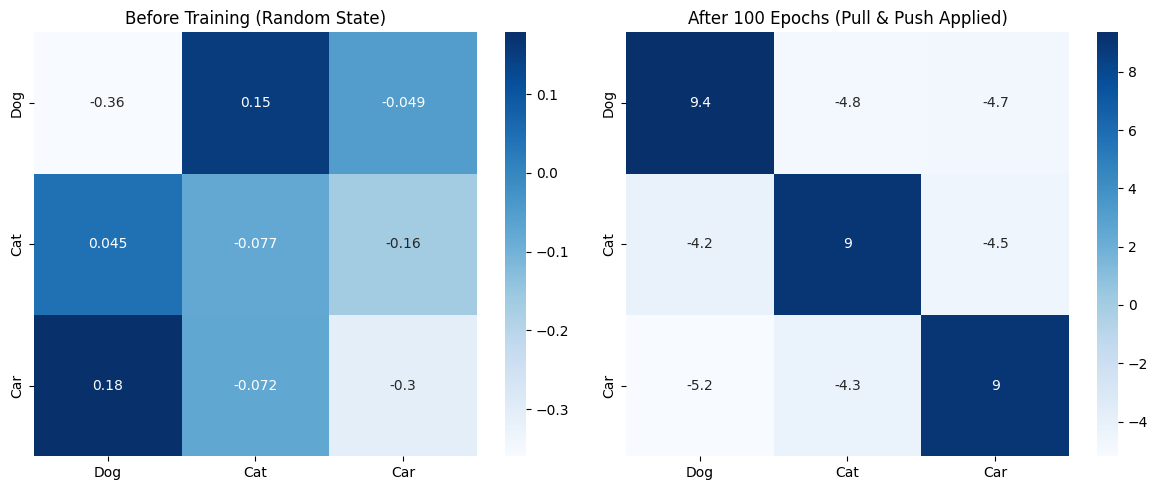

In [1]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

def train_contrastive_principle():
    torch.manual_seed(42)

    # 3개의 일반적인 객체를 가정 (ex 1. 강아지, 2. 고양이, 3. 자동차)
    batch_size = 3
    embed_dim = 128

    # 학습 전, 완전히 무작위로 초기화된 임베딩 벡터 (모델의 초기 상태와 동일)
    # 파라미터로 설정하여 역전파(Backpropagation)를 통해 학습되도록 함
    image_embeddings = torch.nn.Parameter(torch.randn(batch_size, embed_dim))
    text_embeddings = torch.nn.Parameter(torch.randn(batch_size, embed_dim))

    # 온도를 조절하는 파라미터 (Logit scale)
    temperature = torch.nn.Parameter(torch.tensor(1.0))
    optimizer = optim.Adam([image_embeddings, text_embeddings, temperature], lr=0.1)

    def get_similarity():
        # 코사인 유사도 계산을 위해 벡터 정규화 (길이를 1로 만듦)
        img_norm = F.normalize(image_embeddings, p=2, dim=-1)
        txt_norm = F.normalize(text_embeddings, p=2, dim=-1)
        # 행렬 곱(@)을 통해 모든 쌍의 유사도 계산 후 온도 곱하기
        return (img_norm @ txt_norm.T) * torch.exp(temperature)

    # --- [학습 전 유사도 행렬 저장] ---
    sim_before = get_similarity().detach().numpy()

    # --- [미니 학습 루프 (100회)] ---
    for epoch in range(100):
        optimizer.zero_grad()
        logits = get_similarity()

        # 정답 라벨 생성: 0번 이미지는 0번 텍스트, 1번은 1번... (대각선 행렬)
        labels = torch.arange(batch_size)

        # InfoNCE Loss (대조 손실) 계산
        # 이미지를 기준으로 텍스트를 맞추는 Loss + 텍스트를 기준으로 이미지를 맞추는 Loss
        loss_i2t = F.cross_entropy(logits, labels)
        loss_t2i = F.cross_entropy(logits.T, labels)
        loss = (loss_i2t + loss_t2i) / 2

        loss.backward()
        optimizer.step()

    # --- [학습 후 유사도 행렬 저장] ---
    sim_after = get_similarity().detach().numpy()

    # --- [결과 시각화] ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 보편적인 주제로 라벨 변경
    labels_list = ["Dog", "Cat", "Car"]

    sns.heatmap(sim_before, annot=True, cmap="Blues", ax=axes[0],
                xticklabels=labels_list, yticklabels=labels_list)
    axes[0].set_title("Before Training (Random State)")

    sns.heatmap(sim_after, annot=True, cmap="Blues", ax=axes[1],
                xticklabels=labels_list, yticklabels=labels_list)
    axes[1].set_title("After 100 Epochs (Pull & Push Applied)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_contrastive_principle()

학습 이전에는 이미지와 텍스트가 제대로 매칭 되지 않았다는 것을 유사도 검사를 통해서 확인 할 수 있었습니다.
하지만 학습(정렬) 이후에는 제대로 정렬된 모습을 확인할 수 있습니다.

이런 Contrastive learning 기법을 사용한 대표적인 모델이 CLIP 모델 입니다.

CLIP 모델의 성능을 확인하기 위한 이미지를 다운받겠습니다. 혹시 넣어보고 싶은 이미지가 있다면 직접 url 수정하여 입력해주세요!

이미지를 다운로드하는 중...



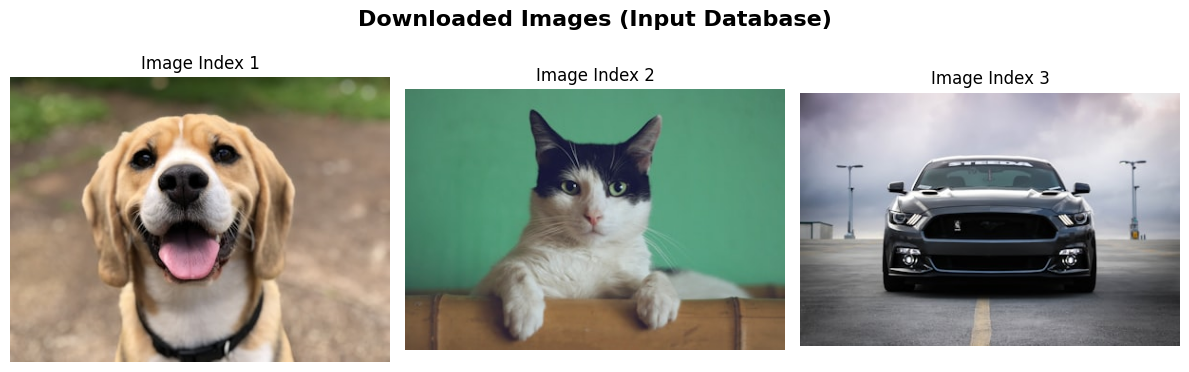

In [2]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# 테스트에 사용할 (강아지, 고양이, 자동차) 이미지 URL 3장
image_urls = [
    "https://images.unsplash.com/photo-1543466835-00a7907e9de1?q=80&w=400&auto=format&fit=crop", # 강아지
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=400&auto=format&fit=crop", # 고양이
    "https://images.unsplash.com/photo-1494976388531-d1058494cdd8?q=80&w=400&auto=format&fit=crop"  # 자동차
]

print("이미지를 다운로드하는 중...\n")
images = []

for url in image_urls:
    response = requests.get(url)
    response.raise_for_status()
    images.append(Image.open(BytesIO(response.content)).convert("RGB"))

# 다운로드 이미지 시각화
fig1, axes1 = plt.subplots(1, 3, figsize=(12, 4))
fig1.suptitle("Downloaded Images (Input Database)", fontsize=16, fontweight='bold')

for i, img in enumerate(images):
    axes1[i].imshow(img)
    axes1[i].axis('off')
    axes1[i].set_title(f"Image Index {i+1}")

plt.tight_layout()
plt.show()

사전 학습된 CLIP 모델을 불러오는 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

특징 벡터 추출 및 유사도 계산 중...



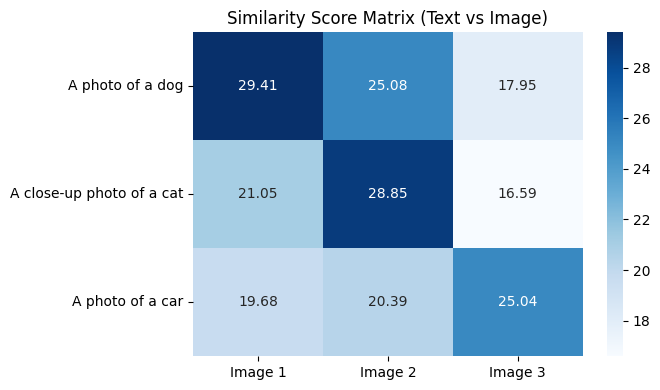

In [3]:
import torch
from transformers import AutoProcessor, CLIPModel
import matplotlib.pyplot as plt
import seaborn as sns

print("사전 학습된 CLIP 모델을 불러오는 중...")
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = AutoProcessor.from_pretrained(model_name)

# 일반적인 주제에 맞춘 영문 텍스트 쿼리 리스트
text_queries = [
    "A photo of a dog",
    "A close-up photo of a cat",
    "A photo of a car"
]

print("특징 벡터 추출 및 유사도 계산 중...\n")
# 첫 번째 코드 영역에서 만든 images 변수를 모델의 입력값으로 사용합니다.
inputs = processor(text=text_queries, images=images, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = model(**inputs)
    # 텍스트와 이미지 간의 유사도 점수 산출
    logits_per_text = outputs.logits_per_text

# 텐서를 다루기 쉬운 넘파이 배열로 변환
similarity_matrix = logits_per_text.cpu().numpy()

# 매트릭스를 직관적인 히트맵으로 시각화
plt.figure(figsize=(7, 4))
sns.heatmap(similarity_matrix, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=[f"Image {i+1}" for i in range(len(images))],
            yticklabels=text_queries)
plt.title("Similarity Score Matrix (Text vs Image)")
plt.tight_layout()
plt.show()

이제 계산된 결과를 시각화하겠습니다.

[A photo of a dog] 텍스트는 1번째 이미지와 가장 잘 매칭되었습니다.
[A close-up photo of a cat] 텍스트는 2번째 이미지와 가장 잘 매칭되었습니다.
[A photo of a car] 텍스트는 3번째 이미지와 가장 잘 매칭되었습니다.


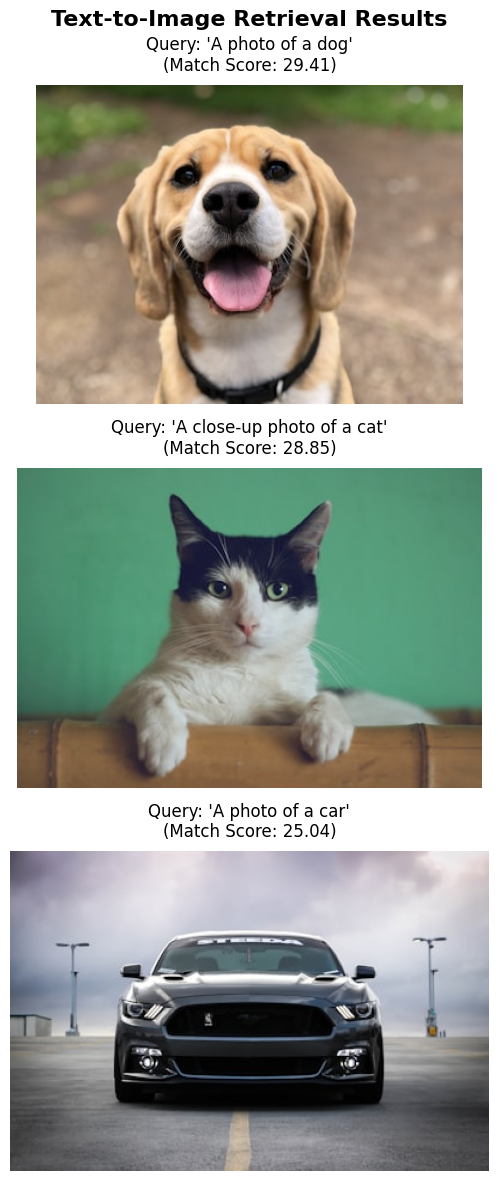

In [4]:
# 이전 블록에서 계산된 text_queries, images, logits_per_text 변수를 사용합니다.

fig2, axes2 = plt.subplots(len(text_queries), 1, figsize=(6, 12))
fig2.suptitle("Text-to-Image Retrieval Results", fontsize=16, fontweight='bold')

for i, query in enumerate(text_queries):
    # 특정 텍스트 쿼리(i)에 대해 가장 유사도가 높은 이미지 인덱스 찾기
    best_image_idx = logits_per_text[i].argmax().item()
    score = logits_per_text[i][best_image_idx].item()

    # 매칭된 이미지 그리기
    axes2[i].imshow(images[best_image_idx])
    axes2[i].axis('off')
    axes2[i].set_title(f"Query: '{query}'\n(Match Score: {score:.2f})", fontsize=12, pad=10)

    print(f"[{query}] 텍스트는 {best_image_idx + 1}번째 이미지와 가장 잘 매칭되었습니다.")

plt.tight_layout()
plt.show()

## (2) Matching Alignment(ITM)

Matching Alignment 기법은 BLIP 모델에서 사용된 기법으로 이미지의 더 구체적인 판별을 위해서 고안되었습니다.
이미지의 세부 조각(Patch)와 텍스트의 세부 단어(Token)들을 정밀하게 융합하는 과정을 거칩니다.

원래는 ITM 내부의 Cross-Attentnion 메커니즘이 자체적인 변환 행렬 $(W_q ,W_k, W_v)$로 차원을 맞추고 정보를 섞어줍니다. 하지만 저희는 보다 편한 이해를 위해서 가장 단순한 Fusion 방식(Concat)을 사용하기 위해 같은 차원으로 투영하고 진행하도록 하겠습니다.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. 간단한 ITM 모델 정의 (Simple Image-Text Matching Model)
# ==========================================

class SimpleITM(nn.Module):
    def __init__(self, image_dim, text_dim, hidden_dim):
        super(SimpleITM, self).__init__()

        # 이미지와 텍스트 특징을 동일한 차원으로 투영(Projection)
        self.image_proj = nn.Linear(image_dim, hidden_dim)
        self.text_proj = nn.Linear(text_dim, hidden_dim)

        # 두 특징을 융합(Fusion)한 후 이진 분류를 수행하는 레이어
        # 입력 차원이 2배(hidden_dim * 2)인 이유는 두 벡터를 이어붙일(Concat) 것이기 때문
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) # 최종 출력은 1개의 실수값
        )

    def forward(self, image_features, text_features):
        # 1. 각각의 차원을 맞춰줍니다.
        img_emb = torch.relu(self.image_proj(image_features))
        txt_emb = torch.relu(self.text_proj(text_features))

        # 2. 특징 융합 (Cross-modal Fusion)
        # 여기서는 가장 단순한 방법인 결합(Concatenation)을 사용합니다.
        # 실제 BLIP 모델에서는 이 부분을 Cross-Attention으로 정밀하게 섞어 [CLS_fusion]을 만듭니다.
        fused_features = torch.cat((img_emb, txt_emb), dim=1)

        # 3. 이진 분류 (Match: 1, Mismatch: 0) 예측
        logits = self.classifier(fused_features)
        return logits

 하이퍼파라미터 및 가짜 데이터(Dummy Data) 생성하겠습니다.
 - 이미지: 512 차원, 텍스트 256 차원
 - 프로젝션 디멘션 : 128
 - 손실 함수 BCEWithLogitsLoss
- 옵티마이저 : Adam

실제로 정답인지 아닌지는 모델이 통계적 규칙성을 통해 스스로 학습합니다. 그 규칙성을 바탕으로 Attention Score를 계산하여 알아서 정답 라벨을 생성할 수 있게 됩니다.

In [7]:
# ==========================================
batch_size = 4
image_dim = 512  # 가짜 이미지 차원
text_dim = 256 # 가짜 텍스트 차원
hidden_dim = 128

# 모델 선언
model = SimpleITM(image_dim, text_dim,hidden_dim)

# 손실 함수와 옵티마이저
criterion = nn.BCEWithLogitsLoss()   #hint : nn Class 내부에 구현되어 있음!
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 가짜 입력 데이터
images = torch.randn(batch_size, image_dim)
texts = torch.randn(batch_size, text_dim)

# 정답 라벨 (y) 가정
# 1.0: 포지티브 페어 (사진과 설명이 일치함)
# 0.0: 네거티브 페어 (사진과 무관한 설명임)
labels = torch.tensor([[1.0], [0.0], [1.0], [0.0]])

이제 학습을 돌려볼까요? 적당히 100번만 해봅시다.

(이 모델은 간소화 되었지만, 실제로 핵심적으로 모델이 학습되는 부분은 Cross-Attention 모듈입니다. q,k,v 행렬이 높은 점수를 부여할 수 있도록 학습됩니다.)

In [9]:
# ==========================================
# 학습 루프 (Training Loop) 실행
# ==========================================
epochs = 100

print("--- ITM 학습 시작 ---")
for epoch in range(epochs):
    # 1. 순전파 (Forward pass): 예측값(p) 계산
    predictions = model( images, texts )

    # 2. 손실 계산 (BCE Loss)
    loss = criterion(predictions, labels)

    # 3. 역전파 및 가중치 업데이트
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 10번마다 결과 출력
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# ==========================================
# 학습 완료 후 결과 확인
# ==========================================
print("\n--- 학습 완료 후 최종 예측 결과 ---")
model.eval()
with torch.no_grad():
    final_logits = model(images, texts)
    # Logit 값을 Sigmoid에 통과시켜 0~1 사이의 확률값(p)으로 변환
    probabilities = torch.sigmoid(final_logits)

    for i in range(batch_size):
        pred_prob = probabilities[i].item()
        true_label = labels[i].item()
        # 0.5 이상이면 Match(1), 미만이면 Mismatch(0)로 판정
        pred_class = "Match(1)" if pred_prob >= 0.5 else "Mismatch(0)"

        print(f"데이터 쌍 {i+1}: 실제 정답={int(true_label)} | 예측 확률={pred_prob:.4f} -> {pred_class}")

--- ITM 학습 시작 ---
Epoch [10/100], Loss: 0.0000
Epoch [20/100], Loss: 0.0000
Epoch [30/100], Loss: 0.0000
Epoch [40/100], Loss: 0.0000
Epoch [50/100], Loss: 0.0000
Epoch [60/100], Loss: 0.0000
Epoch [70/100], Loss: 0.0000
Epoch [80/100], Loss: 0.0000
Epoch [90/100], Loss: 0.0000
Epoch [100/100], Loss: 0.0000

--- 학습 완료 후 최종 예측 결과 ---
데이터 쌍 1: 실제 정답=1 | 예측 확률=1.0000 -> Match(1)
데이터 쌍 2: 실제 정답=0 | 예측 확률=0.0000 -> Mismatch(0)
데이터 쌍 3: 실제 정답=1 | 예측 확률=1.0000 -> Match(1)
데이터 쌍 4: 실제 정답=0 | 예측 확률=0.0000 -> Mismatch(0)


## (3) Generative Alignment

Generative Alignment에 대해서 학습해보도록 하겠습니다.
'생성적 정렬'은 멀티모달 AI에서 이미지나 비디오 같은 시각적 데이터를 바탕으로 AI가 직접 텍스트를 생성해 내면서 두 데이터간의 의미를 맞추는 방식입니다.
간단하게 구조를 살펴보자면, 시각적 정보를 이해하는 Encoder와 텍스트를 만들어내는 Decoder로 이루어져 있습니다. 시각적 특징을 디코더에 Context로 넣어주면, 디코더는 이미지를 참고하여 다음에 올 단어들을 순차적으로 예측합니다.

이 과정에서 Loss Function으로는 **Cross-Entropy Loss**가 사용됩니다.

##### 이미지 다운(열지말고 실행하세요)

In [10]:
image = "..."



### 이미지 불러와서 확인!

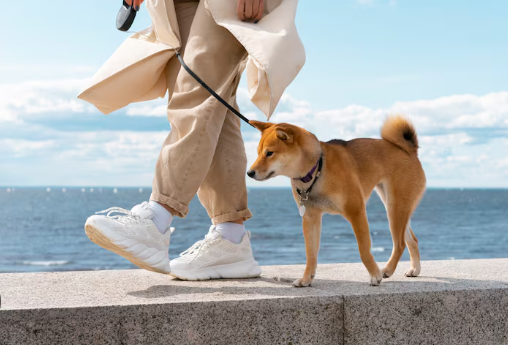

In [11]:
import base64
from PIL import Image
from io import BytesIO

image_data = base64.b64decode(image)
img = Image.open(BytesIO(image_data))

display(img)

다양한 단어의 토큰을 포함한 vocab을 만들었습니다.

다음으로는 생성모델(디코더)를 정의해야 합니다.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

# ==========================================
# 1. 단어 사전(Vocabulary) 구축
# ==========================================
vocab = {
    "<PAD>": 0, "<SOS>": 1, "<EOS>": 2,
    "강아지가": 3, "바다": 4, "옆을": 5, "산책합니다": 6,
    "선수가": 7, "경기장에서": 8, "축구공을": 9, "넘어집니다": 10, "패스합니다": 11,
    "고양이가": 12, "공원을": 13, "뛰어갑니다": 14,
    "사람이": 15, "빠르게": 16
}
idx2word = {v: k for k, v in vocab.items()}
vocab_size = len(vocab)

print(f"현재 구축된 단어 사전의 크기: {vocab_size}개 단어")

# ==========================================
# 2. Generative Alignment 모델 정의
# ==========================================
class ToyImageCaptioningVLM(nn.Module):
    def __init__(self, image_dim, embed_dim, hidden_dim, vocab_size):
        super(ToyImageCaptioningVLM, self).__init__()
        self.image_proj = nn.Linear(image_dim, hidden_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.decoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, image_features, text_tokens):
        hidden = self.image_proj(image_features).unsqueeze(0)
        embedded = self.embedding(text_tokens)
        out, _ = self.decoder(embedded, hidden)
        logits = self.fc_out(out)
        return logits

    def generate(self, image_features, max_len=5):
        hidden = self.image_proj(image_features).unsqueeze(0)
        input_token = torch.tensor([[vocab["<SOS>"]]])
        generated_words = []

        for _ in range(max_len):
            embedded = self.embedding(input_token)
            out, hidden = self.decoder(embedded, hidden)
            logits = self.fc_out(out)
            pred_token = logits.argmax(dim=-1)[:, -1].item()

            if pred_token == vocab["<EOS>"]:
                break

            generated_words.append(idx2word[pred_token])
            input_token = torch.tensor([[pred_token]])

        return " ".join(generated_words)

# ==========================================
# 3. 데이터 준비: img 변수를 바로 Tensor로 변환
# ==========================================

img = img.convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_image_tensor = preprocess(img).unsqueeze(0)
input_image_features = input_image_tensor.mean(dim=[2,3]) # 결과: (1, 3)

현재 구축된 단어 사전의 크기: 17개 단어


학습 전 문장 생성을 테스트 하고 학습을 진행해보도록 하겠습니다.


In [13]:
# ==========================================
# 4. 하이퍼파라미터 및 모델 세팅
# ==========================================
image_dim = 3
embed_dim = 64
hidden_dim = 128
batch_size = 1

model = ToyImageCaptioningVLM(image_dim, embed_dim, hidden_dim, vocab_size) #위에서 선언한 모델 생성(인자는 모델 선언 시 init 참고)

criterion = nn.CrossEntropyLoss(ignore_index=vocab["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=0.01)

input_texts = torch.tensor([[vocab["<SOS>"], vocab["강아지가"], vocab["바다"], vocab["옆을"], vocab["산책합니다"]]])
target_texts = torch.tensor([[vocab["강아지가"], vocab["바다"], vocab["옆을"], vocab["산책합니다"], vocab["<EOS>"]]])

# ==========================================
# 5. 학습 전 문장 생성 테스트
# ==========================================
print("--- [비교] 학습 전 문장 생성 테스트 ---")
model.eval() # 평가 모드로 전환
with torch.no_grad():
    generated_sentence_before = model.generate(input_image_features)
    print(f"학습 전 AI가 생성한 문장: '{generated_sentence_before}'\n")

# ==========================================
# 6. 학습 루프 (Training)
# ==========================================
print("--- Generative Alignment 학습 시작 ---")
model.train() # 다시 학습 모드로 전환
epochs = 50
for epoch in range(epochs):
    logits = model(input_image_features, input_texts)

    logits_flat = logits.view(-1, vocab_size)
    target_flat = target_texts.view(-1)

    loss = criterion(logits_flat, target_flat)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

--- [비교] 학습 전 문장 생성 테스트 ---
학습 전 AI가 생성한 문장: '사람이 강아지가 <SOS> 강아지가 <SOS>'

--- Generative Alignment 학습 시작 ---
Epoch [10/50], Loss: 0.0018
Epoch [20/50], Loss: 0.0001
Epoch [30/50], Loss: 0.0001
Epoch [40/50], Loss: 0.0000
Epoch [50/50], Loss: 0.0000


In [14]:
# ==========================================
# 7. 학습 완료 후 문장 생성 테스트
# ==========================================
print("\n--- [비교] 학습 완료 후 문장 생성 테스트 ---")
model.eval()
with torch.no_grad():
    generated_sentence_after = model.generate(input_image_features)
    print(f"학습 후 AI가 생성한 정렬된 문장: '{generated_sentence_after}'")


--- [비교] 학습 완료 후 문장 생성 테스트 ---
학습 후 AI가 생성한 정렬된 문장: '강아지가 바다 옆을 산책합니다'


---

# [모델링] 3번

앞으로 연구나 프로젝트를 진행하면서 새로운 모델을 만들고 학습시키에는 자원이 너무 부족합니다 ㅠㅠ 그러다보니 특수한 도메인에서의 성능을 높이기 위한 연구들이 많이 이루어지고 있습니다. 이번 파트에서는 도메인에 대한 파인 튜닝을 진행해보려고 합니다.

사용 데이터셋 : ariG23498/flickr8k

멀티모달 AI(Vision-Language) 분야에서 이미지-텍스트 정렬(Image-Text Alignment) 및 이미지 캡셔닝(Image Captioning) 모델을 학습할 때 사용하는 가장 대표적인 입문용 표준 데이터셋으로 8000장의 보편적인 이미지(일상생활, 동물, 스포츠 등)에 대해서 5개의 서로 다른 묘사 문장이 캡셔닝되어있습니다.

(https://huggingface.co/datasets/ariG23498/flickr8k)

먼저 데이터셋을 다운받고 특화를 위한 도메인 키워드를 입력하여 데이터셋을 필터링 하겠습니다.

!!!!! 필터링 좁게 하는 것을 추천합니다. 데이터 1000장 아래로 잡히도록 하면 좋을듯? 아니면 너무 오래걸려요.. !!!!!

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset
from tqdm import tqdm
import random

# ==========================================
# 1. 특수 목적 데이터셋 필터링 및 로드
# ==========================================
print("데이터셋을 다운로드하고 필터링합니다...")
raw_dataset = load_dataset("ariG23498/flickr8k", split="train")

# [도메인 특화 로직] (ex. 스포츠, 공, 달리기 등 -> 영어 캡션이니까 영어로!)
action_keywords = ['soccer']

def filter_action_images(example):
    text_data =  example.get('caption')

    # 데이터가 5개의 문장이 담긴 리스트(List) 형태라면 하나의 거대한 문자열로 합쳐서 검사
    if isinstance(text_data, list):
        caption_str = " ".join(text_data).lower()
    else:
        caption_str = str(text_data).lower()

    return any(keyword in caption_str for keyword in action_keywords)

action_dataset = raw_dataset.filter(filter_action_images)
print(f"필터링 완료: 총 {len(raw_dataset)}장 중 관련 이미지 {len(action_dataset)}장 추출됨.")

# ==========================================
# 2. PyTorch 커스텀 데이터셋 정의
# ==========================================
class ActionCLIPDataset(Dataset):
    def __init__(self, hf_dataset, processor):
        self.dataset = hf_dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert("RGB") # PIL 이미지 보장

        text_data = item.get('caption')

        # 5개의 문장 리스트일 경우, 학습의 다양성을 위해 매번 랜덤으로 1개를 골라서 학습에 사용
        if isinstance(text_data, list):
            caption = random.choice(text_data)
        else:
            caption = str(text_data)

        # CLIP Processor 전처리
        inputs = self.processor(
            text=caption,
            images=image,
            return_tensors="pt",
            padding="max_length",
            max_length=77,
            truncation=True
        )

        return {key: val.squeeze(0) for key, val in inputs.items()}

# 이후 3번(모델 초기화) 및 4번(학습 루프) 코드는 기존과 동일하게 사용하시면 됩니다!

데이터셋을 다운로드하고 필터링합니다...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/710 [00:00<?, ?B/s]

data/train-00000-of-00012.parquet:   0%|          | 0.00/95.0M [00:00<?, ?B/s]

data/train-00001-of-00012.parquet:   0%|          | 0.00/96.7M [00:00<?, ?B/s]

...

data/train-00010-of-00012.parquet:   0%|          | 0.00/101M [00:00<?, ?B/s]

data/train-00011-of-00012.parquet:   0%|          | 0.00/100M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40455 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40455 [00:00<?, ? examples/s]

필터링 완료: 총 40455장 중 관련 이미지 549장 추출됨.


이제 모델을 학습시켜보겠습니다. 위에서 학습했던 ITC를 이용하여 파인튜닝을 해봅시다.

In [ ]:
# ==========================================
# 3. 모델 및 프로세서 초기화
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 중인 디바이스: {device}")

# OpenAI의 기본 CLIP 모델 불러오기
model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id).to(device)

# 빠른 테스트와 메모리 절약을 위해 Vision Transformer(이미지) 부분의 가중치를 얼리고(Freeze),
# Text 인코더와 최종 투영 계층(Projection Layer)만 미세 조정(Fine-tuning)하도록 설정합니다.
for param in model.vision_model.parameters():
    param.requires_grad = False

# 데이터 로더 세팅
train_dataset = ActionCLIPDataset(action_dataset, processor)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 옵티마이저 설정
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5)
loss_fn = nn.CrossEntropyLoss()

# ==========================================
# 4. ITC (대조 학습) 루프 실행
# ==========================================

epochs = 3
# 출력 주기를 설정합니다 (예: 10번의 배치마다 한 번씩만 화면에 Loss 업데이트)
log_steps = 10

print("\n--- 도메인 CLIP(ITC) 파이프라인 학습 시작 ---")

model.train()
for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    # enumerate를 추가하여 현재 배치의 순서(step)를 추적합니다.
    for step, batch in enumerate(progress_bar):
        optimizer.zero_grad()

        # 데이터를 GPU/CPU로 이동
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # CLIP 모델 순전파
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # 대칭 교차 엔트로피 손실(Symmetric Cross Entropy) 계산
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        labels = torch.arange(logits_per_image.size(0), device=device)

        loss_i = loss_fn(logits_per_image, labels)
        loss_t = loss_fn(logits_per_text, labels)
        loss = (loss_i + loss_t) / 2

        # 역전파 및 가중치 업데이트
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # 💡 [핵심 수정 부분] 지정한 주기(log_steps)마다 혹은 마지막 배치에만 화면을 업데이트합니다.
        if (step + 1) % log_steps == 0 or (step + 1) == len(train_dataloader):
            # 현재까지 진행된 배치의 평균 Loss를 계산하여 보여줍니다. (훨씬 안정적인 지표)
            avg_loss_so_far = total_loss / (step + 1)
            progress_bar.set_postfix({"Avg Loss": f"{avg_loss_so_far:.4f}"})

    # 한 에포크가 끝날 때 최종 평균 Loss 출력
    print(f"👉 Epoch {epoch+1} 최종 평균 손실: {total_loss / len(train_dataloader):.4f}\n")

print("✅ 학습이 완료되었습니다. 이제 모델이 해당 도메인에 더 민감하게 반응합니다.")

이제 파인튜닝의 결과를 확인해 볼 시간입니다.
본인이 학습시킨 모델을 이용해서 테스트를 진행하시면 됩니다.
이미지를 한장 넣고, 후보 캡션들을 입력하여 각 문장의 정답 확률을 출력해주세요. 다양한 결과를 위해 캡션은 파인 튜닝 도메인 이외의 문장도 포함시켜주세요! 기존의 CLIP 모델은 4억개 이상의 쌍을 이용하여 학습을 하였기 때문에 파인튜닝의 결과가 모델에 큰 영향을 주지 못하였을 수 있습니다.(우린 데이터도 적고 에포크도 적고..) 그러니 문장의 일치 확률에 집중하지 말고, 앞으로 우리가 이런식으로 사용할 수 있겠구나 하는 부분만 잘 느껴주세요!

+ 이미지는 url로 넣어도 괜찮고, 업로드해도 괜찮습니다(그러면 코드 약간 수정). 잘 출력 되는 것만 보여주세요.

In [ ]:
import torch
import torch.nn.functional as F
import requests
from PIL import Image
from io import BytesIO

# ==========================================
# 1. 평가를 위한 테스트 이미지 로드
# ==========================================
test_url = "(todo)"
try:
    response = requests.get(test_url, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    test_image = Image.open(BytesIO(response.content)).convert("RGB")
    print("✅ 테스트용 이미지 로드 성공!")
    display(test_image.resize((400, 300)))
except Exception as e:
    print(f"❌ 이미지를 불러올 수 없습니다: {e}")

# ==========================================
# 2. 모델이 구분해야 할 텍스트 후보군 작성(4개 이상의 문장을 넣어주세요)
# ==========================================
candidate_captions = [
     (todo)
]

# ==========================================
# 3. 모델 추론 (Inference)
# ==========================================
model.eval() # 평가 모드 전환
with torch.no_grad():
    # 텍스트 후보군과 이미지를 전처리하여 텐서로 변환
    inputs = processor(
        text=candidate_captions,
        images=test_image,
        return_tensors="pt",
        padding=True
    ).to(device)

    # 특징 추출 및 유사도(Logits) 계산
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image  # 이미지 벡터 기준의 텍스트 유사도 점수

    # ==========================================
    # 4. 확률(Probability) 변환 및 결과 출력
    # ==========================================
    # Softmax 함수를 적용하여 각 문장이 정답일 확률을 0~100%로 변환합니다.
    probs = F.softmax(logits_per_image, dim=1).cpu().numpy()[0]

print("\n--- 🎯 도메인 특화 학습 결과 검증 ---")
print("모델이 이미지를 보고 다음 문장들이 상황과 일치할 확률을 계산했습니다:\n")

# 결과를 보기 좋게 정렬하여 출력
for i, caption in enumerate(candidate_captions):
    print(f"[{probs[i] * 100:>5.1f}%] : {caption}")

고생하셨습니다!
잊지말고 제출까지 잘 해주세요~